# SHAP Explanation for Selected SPARCS Model

This notebook generates SHAP-based explanations for the selected best model.

The selected model is loaded from the model comparison output. SHAP is used to identify the most influential features contributing to a prolonged length of stay prediction.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
!pip install -q shap joblib lightgbm

In [38]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import shap

In [39]:
BASE_DIR = "/content/drive/MyDrive/FYP/SPARCS"

PROCESSED_PATH = f"{BASE_DIR}/processed/sparcs_2024_processed.csv"
SPLIT_DIR = f"{BASE_DIR}/splits"
MODEL_DIR = f"{BASE_DIR}/models"
RESULT_DIR = f"{BASE_DIR}/results"
XAI_DIR = f"{BASE_DIR}/xai"

os.makedirs(XAI_DIR, exist_ok=True)

In [40]:
# Load Selected Model Info

best_model_info = joblib.load(f"{MODEL_DIR}/best_model_selection.joblib")

best_model_info

{'best_model': 'LightGBM',
 'best_model_file': 'lightgbm_sparcs_los_pipeline.joblib',
 'best_metadata_file': 'lightgbm_sparcs_metadata.joblib',
 'selection_reason': 'Selected based on highest test ROC-AUC and PR-AUC among models with recall above 0.70.',
 'test_metrics': {'model': 'LightGBM',
  'dataset': 'SPARCS 2024',
  'split': 'test',
  'threshold': 0.5999999999999999,
  'roc_auc': 0.878119525989046,
  'pr_auc': 0.7111659540917288,
  'accuracy': 0.8174795378606481,
  'precision': 0.6013905621304104,
  'recall': 0.7209159642449242,
  'f1': 0.6557512170411519}}

In [41]:
# Load Model Pipeline and Metadata
# pipleline include preprocessing + model
# SHAP need to access the preprocessor and model in the pipeline

best_model_path = f"{MODEL_DIR}/{best_model_info['best_model_file']}"
best_metadata_path = f"{MODEL_DIR}/{best_model_info['best_metadata_file']}"

pipeline = joblib.load(best_model_path)
metadata = joblib.load(best_metadata_path)

print("Loaded model:", metadata["model_name"])
print("Selected threshold:", metadata["selected_threshold"])

Loaded model: LightGBM
Selected threshold: 0.5999999999999999


In [42]:
# Load Dataset and Split Files

df = pd.read_csv(PROCESSED_PATH, low_memory=False)

feature_columns = joblib.load(f"{SPLIT_DIR}/feature_columns.joblib")
feature_schema = joblib.load(f"{SPLIT_DIR}/feature_schema.joblib")

test_idx = np.load(f"{SPLIT_DIR}/test_idx.npy")

X = df[feature_columns].copy()
y = df["prolonged_los"].copy()

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print("X_test shape:", X_test.shape)

X_test shape: (439348, 13)


In [43]:
# Extract Preprocessor and Model
# SHAP is meant to explain the LightGBM model, so we need to transform X first

preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

In [44]:
# Transform Test Data

X_test_transformed = preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (439348, 1194)


In [45]:
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

In [46]:
# Get Transformed Feature Names

feature_names = preprocessor.get_feature_names_out()

feature_names[:20], len(feature_names)

(array(['cat__Age Group_0-17', 'cat__Age Group_18-29',
        'cat__Age Group_30-49', 'cat__Age Group_50-69',
        'cat__Age Group_70 or Older', 'cat__Gender_F', 'cat__Gender_M',
        'cat__Gender_U', 'cat__Race_Black/African American',
        'cat__Race_Multi-racial', 'cat__Race_Other Race',
        'cat__Race_White', 'cat__Ethnicity_Multi-ethnic',
        'cat__Ethnicity_Not Span/Hispanic',
        'cat__Ethnicity_Spanish/Hispanic', 'cat__Ethnicity_Unknown',
        'cat__Type of Admission_Elective',
        'cat__Type of Admission_Emergency',
        'cat__Type of Admission_Newborn',
        'cat__Type of Admission_Not Available'], dtype=object),
 1194)

In [47]:
# Create SHAP Explainer
# TreeExplainer is tree-based models of SHAP explainer

explainer = shap.TreeExplainer(model)

In [48]:
# Compute SHAP Values for Sample

sample_size = min(1000, X_test.shape[0])

sample_indices = X_test.sample(
    n=sample_size,
    random_state=42
).index

X_original_sample = X_test.loc[sample_indices].copy()
X_shap_sample_transformed = preprocessor.transform(X_original_sample)

if hasattr(X_shap_sample_transformed, "toarray"):
    X_shap_sample = X_shap_sample_transformed.toarray()
else:
    X_shap_sample = X_shap_sample_transformed

shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


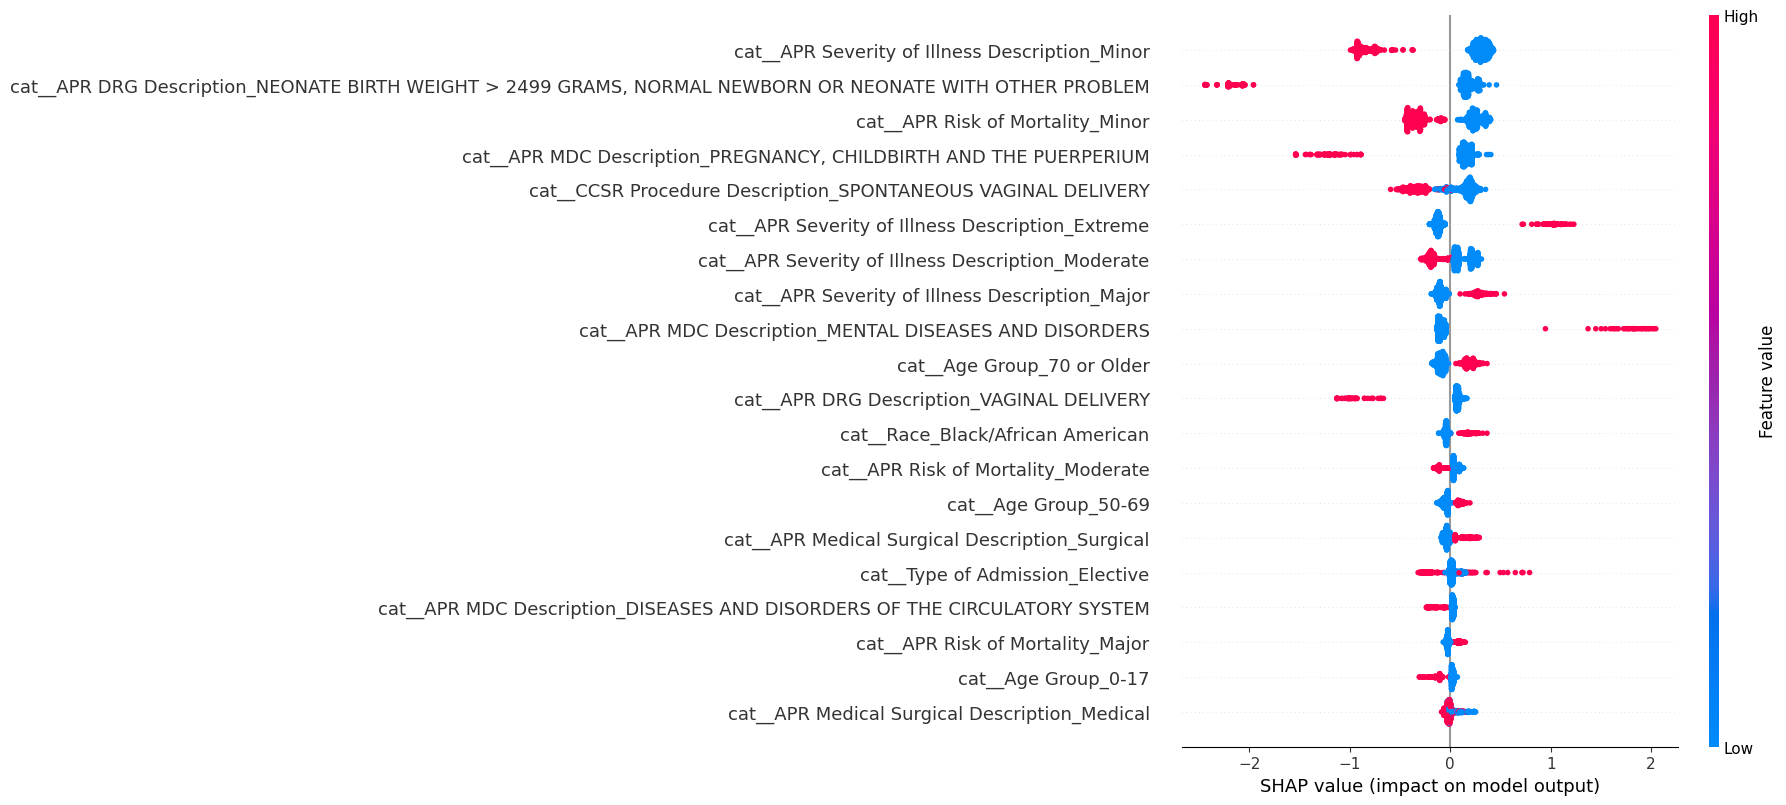

In [49]:
# Global SHAP Summary Plot
# Overall Influential Features

shap.summary_plot(
    shap_values_positive,
    X_shap_sample,
    feature_names=feature_names,
    max_display=20
)

In [50]:
# Aggregate One-Hot SHAP Values Back to Original Features

def clean_transformed_name(name):
    if name.startswith("num__"):
        return name.replace("num__", "")

    if name.startswith("cat__"):
        raw = name.replace("cat__", "")
        for feature in feature_columns:
            prefix = f"{feature}_"
            if raw.startswith(prefix):
                return feature

    return name

original_feature_names = [clean_transformed_name(name) for name in feature_names]

In [51]:
shap_abs = np.abs(shap_values_positive)

global_importance = {}

for idx, original_feature in enumerate(original_feature_names):
    global_importance.setdefault(original_feature, 0)
    global_importance[original_feature] += shap_abs[:, idx].mean()

global_importance_df = pd.DataFrame([
    {
        "feature": feature,
        "label": feature_schema.get(feature, {}).get("label", feature),
        "mean_abs_shap": value
    }
    for feature, value in global_importance.items()
])

global_importance_df["impact_percentage"] = (
    global_importance_df["mean_abs_shap"] /
    global_importance_df["mean_abs_shap"].sum()
) * 100

global_importance_df = global_importance_df.sort_values(
    by="impact_percentage",
    ascending=False
)

global_importance_df.head(15)

,feature,label,mean_abs_shap,impact_percentage
9,APR Severity of Illness Description,Severity of Illness,0.971116,23.615571
7,APR DRG Description,APR DRG,0.757646,18.424419
8,APR MDC Description,Major Diagnosis Category,0.599974,14.590159
6,CCSR Procedure Description,Procedure Category,0.503702,12.249024
10,APR Risk of Mortality,Risk of Mortality,0.428520,10.420741
5,CCSR Diagnosis Description,Diagnosis Category,0.274920,6.685496
0,Age Group,Age Group,0.237981,5.787209
4,Type of Admission,Admission Type,0.111643,2.714920
2,Race,Race,0.095491,2.322153
11,APR Medical Surgical Description,Medical or Surgical Case,0.094947,2.308911


In [52]:
# Individual Prediction Explanation Function

def risk_level(probability):
    if probability < 0.33:
        return "Low"
    elif probability < 0.66:
        return "Medium"
    else:
        return "High"

In [53]:
def explain_single_prediction(row_index):
    original_row = X_test.iloc[[row_index]]
    transformed_row = preprocessor.transform(original_row)

    if hasattr(transformed_row, "toarray"):
        transformed_row = transformed_row.toarray()

    probability = pipeline.predict_proba(original_row)[0, 1]
    threshold = metadata["selected_threshold"]
    predicted_class = int(probability >= threshold)

    row_shap_values = explainer.shap_values(transformed_row)

    if isinstance(row_shap_values, list):
        row_shap_values = row_shap_values[1]
    elif len(row_shap_values.shape) == 3:
        row_shap_values = row_shap_values[:, :, 1]

    row_shap_values = row_shap_values[0]

    feature_contributions = {}

    for idx, original_feature in enumerate(original_feature_names):
        feature_contributions.setdefault(original_feature, 0)
        feature_contributions[original_feature] += abs(row_shap_values[idx])

    total_contribution = sum(feature_contributions.values())

    explanation_rows = []

    for feature, contribution in feature_contributions.items():
        impact_percentage = 0 if total_contribution == 0 else (contribution / total_contribution) * 100

        raw_value = original_row.iloc[0][feature]

        if pd.isna(raw_value):
            display_value = "Not Available"
        else:
            display_value = str(raw_value)

        explanation_rows.append({
            "feature": feature,
            "label": feature_schema.get(feature, {}).get("label", feature),
            "value": display_value,
            "impact_percentage": impact_percentage
        })

    explanation_df = pd.DataFrame(explanation_rows).sort_values(
        by="impact_percentage",
        ascending=False
    )

    return {
        "probability": probability,
        "prolonged_los": "Yes" if predicted_class == 1 else "No",
        "risk_level": risk_level(probability),
        "top_features": explanation_df.head(8)
    }

In [54]:
# Test Individual Explanation

explanation = explain_single_prediction(0)

print("Probability:", explanation["probability"])
print("Prolonged LOS:", explanation["prolonged_los"])
print("Risk Level:", explanation["risk_level"])

explanation["top_features"]

Probability: 0.47661938167420104
Prolonged LOS: No
Risk Level: Medium


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,feature,label,value,impact_percentage
9,APR Severity of Illness Description,Severity of Illness,Major,25.535442
6,CCSR Procedure Description,Procedure Category,Not Available,16.435317
7,APR DRG Description,APR DRG,OTHER PNEUMONIA,15.034710
10,APR Risk of Mortality,Risk of Mortality,Major,12.592373
8,APR MDC Description,Major Diagnosis Category,DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM,10.530334
0,Age Group,Age Group,70 or Older,9.881124
5,CCSR Diagnosis Description,Diagnosis Category,PNEUMONIA (EXCEPT THAT CAUSED BY TUBERCULOSIS),4.459717
11,APR Medical Surgical Description,Medical or Surgical Case,Medical,2.270890


In [55]:
# Generate Clinical Recommendations
# This approach doesn't involve having an AI model automatically generate recommendations.
# Instead, it uses model results + SHAP top features to generate controllable and interpretable recommendations.


def generate_recommendations(prediction_result):
    recommendations = []

    probability = prediction_result["probability"]
    risk = prediction_result["risk_level"]
    top_features = prediction_result["top_features"]

    if risk == "High":
        recommendations.append("Prioritize early discharge planning and multidisciplinary care coordination.")
        recommendations.append("Review the patient for high-risk clinical needs and allocate additional monitoring resources.")
    elif risk == "Medium":
        recommendations.append("Monitor the patient closely and review discharge readiness during daily rounds.")
        recommendations.append("Consider early intervention for modifiable factors contributing to prolonged stay.")
    else:
        recommendations.append("Continue standard care pathway while monitoring for changes in clinical condition.")

    top_labels = top_features["label"].tolist()

    if "Severity of Illness" in top_labels:
        recommendations.append("Review severity-related clinical factors and ensure appropriate care escalation if needed.")

    if "Risk of Mortality" in top_labels:
        recommendations.append("Consider senior clinical review for patients with elevated mortality risk indicators.")

    if "Emergency Department Visit" in top_labels:
        recommendations.append("Assess emergency admission factors that may require additional care planning.")

    if "Medical or Surgical Case" in top_labels:
        recommendations.append("Coordinate with the relevant medical or surgical team to support timely care progression.")

    return recommendations

In [56]:
recommendations = generate_recommendations(explanation)

recommendations

['Monitor the patient closely and review discharge readiness during daily rounds.',
 'Consider early intervention for modifiable factors contributing to prolonged stay.',
 'Review severity-related clinical factors and ensure appropriate care escalation if needed.',
 'Consider senior clinical review for patients with elevated mortality risk indicators.',
 'Coordinate with the relevant medical or surgical team to support timely care progression.']

In [57]:
# Save SHAP Global Importance and Sample Explanation

global_importance_df.to_csv(f"{XAI_DIR}/lightgbm_global_shap_importance.csv", index=False)

sample_explanation = explanation["top_features"].copy()
sample_explanation.to_csv(f"{XAI_DIR}/sample_prediction_explanation.csv", index=False)

joblib.dump(
    {
        "global_importance": global_importance_df,
        "sample_explanation": sample_explanation,
        "sample_recommendations": recommendations
    },
    f"{XAI_DIR}/shap_explanation_outputs.joblib"
)

print("Saved SHAP explanation outputs.")

Saved SHAP explanation outputs.


In [58]:
# Final API Output Example

api_output_example = {
    "prolonged_los": explanation["prolonged_los"],
    "risk_level": explanation["risk_level"],
    "probability": round(float(explanation["probability"]), 4),
    "top_factors": (
        explanation["top_features"]
        .head(5)
        .assign(
            impact_percentage=lambda df: df["impact_percentage"].round(2)
        )
        .to_dict(orient="records")
    ),
    "clinical_recommendations": recommendations
}

api_output_example

{'prolonged_los': 'No',
 'risk_level': 'Medium',
 'probability': 0.4766,
 'top_factors': [{'feature': 'APR Severity of Illness Description',
   'label': 'Severity of Illness',
   'value': 'Major',
   'impact_percentage': 25.54},
  {'feature': 'CCSR Procedure Description',
   'label': 'Procedure Category',
   'value': 'Not Available',
   'impact_percentage': 16.44},
  {'feature': 'APR DRG Description',
   'label': 'APR DRG',
   'value': 'OTHER PNEUMONIA',
   'impact_percentage': 15.03},
  {'feature': 'APR Risk of Mortality',
   'label': 'Risk of Mortality',
   'value': 'Major',
   'impact_percentage': 12.59},
  {'feature': 'APR MDC Description',
   'label': 'Major Diagnosis Category',
   'value': 'DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM',
   'impact_percentage': 10.53}],
 'clinical_recommendations': ['Monitor the patient closely and review discharge readiness during daily rounds.',
  'Consider early intervention for modifiable factors contributing to prolonged stay.',
  'Review

## Summary

SHAP was applied to the selected LightGBM model to explain prolonged LOS predictions.  
Global SHAP importance was calculated to identify the most influential features across the sample.  
Individual prediction explanations were generated by aggregating one-hot encoded SHAP values back to the original feature level.  
A rule-based recommendation function was created using the prediction risk level and top SHAP contributing factors.  
The output format is suitable for integration into the Flask prediction API and healthcare staff dashboard.